# 📊 Statistics Practical Lab

This practical lab focuses on **Hypothesis Testing, Probability Distribution Fitting, A/B Testing, and Correlation Analysis** using a self-created sales dataset.

## 📌 Topics Covered

### 1. Hypothesis Testing on Sales Data

* Define null and alternative hypotheses
* Perform one-sample t-test
* Calculate p-value
* Interpret statistical significance
* Make a business conclusion

### 2. Distribution Fitting with SciPy

* Generate and inspect sales data
* Fit a Normal distribution
* Estimate mean and standard deviation
* Compare actual data with fitted distribution
* Visualize the fitted distribution

### 3. A/B Test Simulation Lab

* Simulate Control and Treatment groups
* Compare conversion rates
* Perform a two-proportion hypothesis test
* Calculate p-value
* Decide whether the new strategy performs better

### 4. Correlation Matrix Heatmap Project

* Calculate correlations between numerical variables
* Create a correlation matrix
* Visualize relationships using a heatmap
* Identify strong positive and negative relationships
* Understand why correlation does not imply causation

---

# 🛠️ Technologies Used

* Python
* NumPy
* Pandas
* SciPy
* Matplotlib
* Seaborn

---

# 📁 Dataset

The sales dataset is **created using Python**, so students do not need to download an external dataset.

---

# 1️⃣ Create Sales Dataset

```python


## 🎓 Learning Outcomes

After completing this practical, students will be able to:

* Formulate statistical hypotheses
* Perform t-tests using SciPy
* Understand p-values and significance levels
* Fit probability distributions using SciPy
* Conduct basic A/B testing
* Compare conversion rates statistically
* Calculate and interpret correlations
* Build correlation heatmaps
* Convert statistical results into business insights


Sales dataset created successfully!
   customer_id  age  website_visits  ad_spend  discount  orders    sales  \
0            1   56               4   1500.49         7       1  5203.58   
1            2   46               1   1838.98         5       5  4996.38   
2            3   32              14   1921.53         5       1  4895.47   
3            4   60              16    209.94         7       6  6134.49   
4            5   25               8    849.59        22       2  6653.93   

   customer_rating  
0             3.75  
1             3.86  
2             4.88  
3             4.62  
4             4.79  
(300, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      300 non-null    int64  
 1   age              300 non-null    int64  
 2   website_visits   300 non-null    int64  
 3   ad_spend         300 non-null    

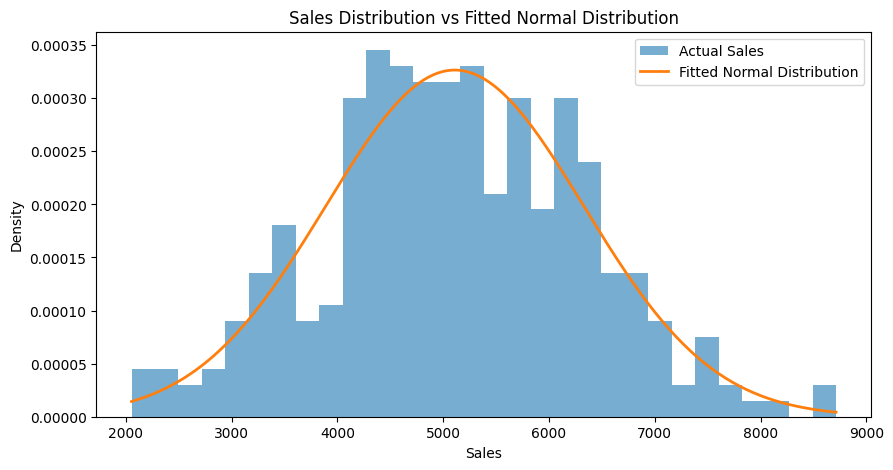

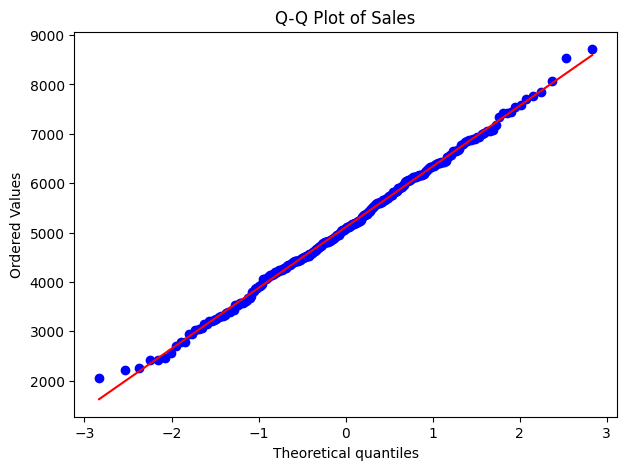

Statistic: 0.31964652456257503
P-value: 0.8522944082251482
No strong evidence against Normality.
Group A conversions: 100
Group B conversions: 148
Group A Conversion Rate: 0.1
Group B Conversion Rate: 0.148
Z-statistic: -3.2565919415542135
P-value: 0.0005637920294497053
Reject H0
The new website significantly improves conversion.


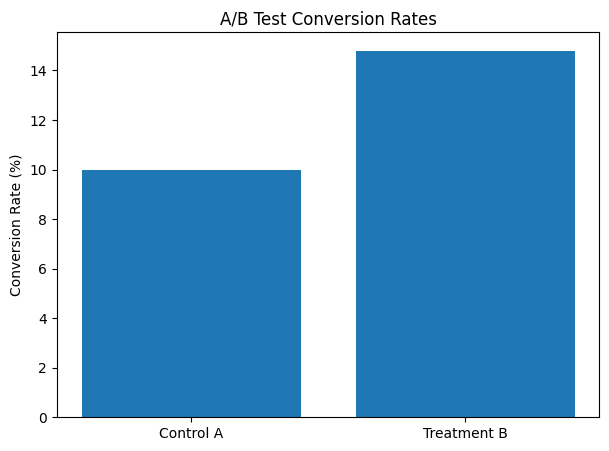

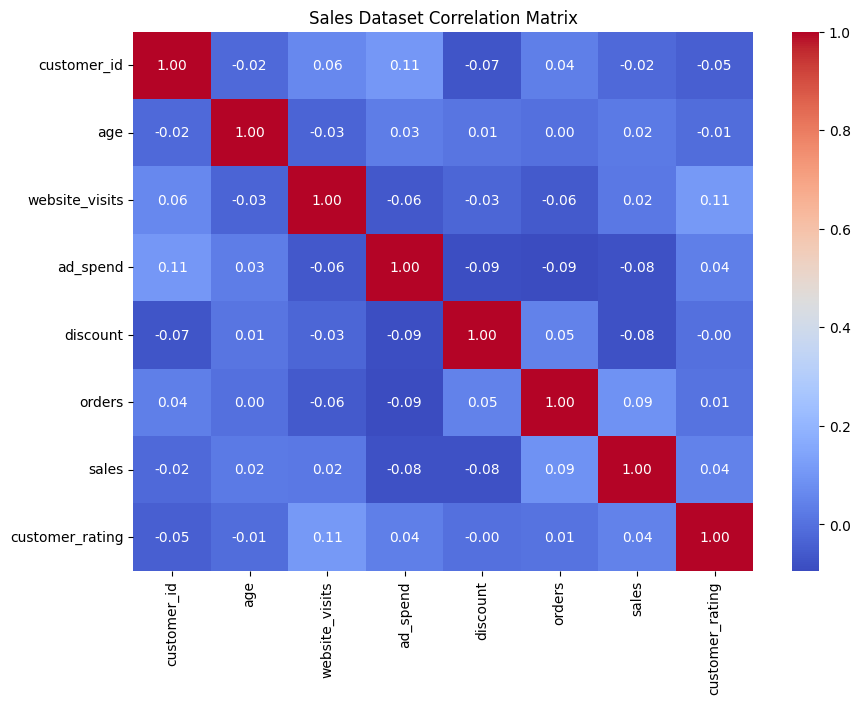

In [5]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 300

sales_data = pd.DataFrame({
    "customer_id": range(1, n + 1),

    "age": np.random.randint(
        18, 65, n
    ),

    "website_visits": np.random.randint(
        1, 20, n
    ),

    "ad_spend": np.round(
        np.random.uniform(100, 2000, n),
        2
    ),

    "discount": np.random.randint(
        0, 31, n
    ),

    "orders": np.random.randint(
        1, 8, n
    ),

    "sales": np.round(
        np.random.normal(5000, 1200, n),
        2
    ),

    "customer_rating": np.round(
        np.random.uniform(2.5, 5.0, n),
        2
    )
})

sales_data.head()


### Save Dataset


sales_data.to_csv(
    "sales_data.csv",
    index=False
)

print("Sales dataset created successfully!")

#  Basic Data Exploration

df = pd.read_csv("sales_data.csv")

print(df.head())
print(df.shape)
df.info()

df.describe()

### Check Missing Values

df.isnull().sum()

### Check Duplicates

df.duplicated().sum()


# Hypothesis Testing on Sales Data

## Business Question

# Suppose the company believes that:

# > **Average monthly sales are greater than ₹5,000.**

# We want to test this statistically.

### Hypotheses

# **Null Hypothesis (H₀):**

# Average sales = ₹5,000

# **Alternative Hypothesis (H₁):**

# Average sales > ₹5,000

# This is a **one-sample right-tailed t-test**.
## Perform Test

from scipy.stats import ttest_1samp

sample_mean = df["sales"].mean()

print("Sample Mean:", sample_mean)

t_stat, p_value = ttest_1samp(
    df["sales"],
    popmean=5000
)

print("T-statistic:", t_stat)
print("P-value:", p_value)
# Decision

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Average sales are statistically different from ₹5,000.")
else:
    print("Fail to reject H0")
    print("There is not enough evidence to reject H0.")

# > **Important:** `ttest_1samp()` is naturally two-sided. For a strictly right-tailed test, use the t-statistic to determine the direction and convert the p-value accordingly:


from scipy.stats import ttest_1samp

t_stat, p_two_sided = ttest_1samp(
    df["sales"],
    5000
)

if t_stat > 0:
    p_value = p_two_sided / 2
else:
    p_value = 1 - (p_two_sided / 2)

print("T-statistic:", t_stat)
print("One-tailed P-value:", p_value)
#  Distribution Fitting with SciPy

# We will check whether **sales approximately follow a Normal distribution**.

import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

sales = df["sales"]

mean = sales.mean()
std = sales.std()

print("Mean:", mean)
print("Standard Deviation:", std)
## Fit Normal Distribution

mu, sigma = stats.norm.fit(sales)

print("Fitted Mean:", mu)
print(
    "Fitted Standard Deviation:",
    sigma
)
## Plot Histogram

plt.figure(figsize=(10, 5))

plt.hist(
    sales,
    bins=30,
    density=True,
    alpha=0.6,
    label="Actual Sales"
)

x = np.linspace(
    sales.min(),
    sales.max(),
    300
)

pdf = stats.norm.pdf(
    x,
    mu,
    sigma
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="Fitted Normal Distribution"
)

plt.title("Sales Distribution vs Fitted Normal Distribution")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.legend()

plt.show()
## Q-Q Plot

import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

stats.probplot(
    sales,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Sales")

plt.show()
## Optional Goodness-of-Fit Test

stat, p_value = stats.normaltest(sales)

print("Statistic:", stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Data significantly deviates from a Normal distribution.")
else:
    print("No strong evidence against Normality.")

#  A/B Test Simulation Lab

# Business Problem

# An e-commerce company wants to test a **new landing page**.

# * **Group A:** Old website
# * **Group B:** New website

# We want to determine whether the new website improves conversion.

# Simulate Data

np.random.seed(42)

n_users = 1000

group_A = np.random.binomial(
    1,
    0.10,
    n_users
)

group_B = np.random.binomial(
    1,
    0.14,
    n_users
)

print("Group A conversions:", group_A.sum())
print("Group B conversions:", group_B.sum())

# Calculate Conversion Rates

conversion_A = group_A.mean()
conversion_B = group_B.mean()

print(
    "Group A Conversion Rate:",
    conversion_A
)

print(
    "Group B Conversion Rate:",
    conversion_B
)

#  Two-Proportion Z-Test

# We test:

# **H₀:** Conversion A = Conversion B

# **H₁:** Conversion B > Conversion A

from statsmodels.stats.proportion import proportions_ztest

conversions = np.array([
    group_A.sum(),
    group_B.sum()
])

sample_sizes = np.array([
    len(group_A),
    len(group_B)
])

z_stat, p_value = proportions_ztest(
    conversions,
    sample_sizes,
    alternative="smaller"
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)
## Decision

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("The new website significantly improves conversion.")
else:
    print("Fail to reject H0")
    print("No statistically significant improvement was detected.")
#  A/B Test Visualization


conversion_rates = [
    conversion_A * 100,
    conversion_B * 100
]

labels = [
    "Control A",
    "Treatment B"
]

plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    conversion_rates
)

plt.ylabel("Conversion Rate (%)")
plt.title("A/B Test Conversion Rates")

plt.show()

# Correlation Matrix Heatmap Project

# First select numerical columns:

numeric_df = df.select_dtypes(
    include="number"
)

correlation_matrix = numeric_df.corr()

correlation_matrix

## Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Sales Dataset Correlation Matrix")

plt.show()
# Find Strong Correlations

corr = df.corr(
    numeric_only=True
)

for column in corr.columns:

    for row in corr.index:

        if column != row:

            value = corr.loc[row, column]

            if abs(value) >= 0.5:

                print(
                    row,
                    "vs",
                    column,
                    "=>",
                    round(value, 2)
                )

# 🔟 Business Interpretation

Students should answer:

### Question 1

Is average sales significantly different from ₹5,000?

### Question 2

Does the sales dataset approximately follow a Normal distribution?

### Question 3

Does the new website significantly improve conversion?

### Question 4

Which variables have the strongest positive correlation with sales?

### Question 5

Which variables have negative correlation with sales?

### Question 6

Does a strong correlation necessarily mean one variable causes another?


# 🎯 Final Assignment

Create a complete **Sales Statistics Analysis Report** containing:

1. Dataset overview
2. Descriptive statistics
3. Hypothesis testing
4. Distribution fitting
5. A/B test
6. Correlation matrix
7. Heatmap
8. Business recommendations

## Expected Folder Structure

```text
Statistics-Practical-Lab/
│
├── README.md
│
├── data/
│   └── sales_data.csv
│
├── notebooks/
│   └── statistics_analysis.ipynb
│
└── outputs/
    ├── sales_distribution.png
    ├── qq_plot.png
    ├── ab_test.png
    └── correlation_heatmap.png
```